# **Fase 3.1 — Agrupamento de Dados: Análise das Notas do ENEM**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.ticker import FuncFormatter
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import confusion_matrix

### **Realizando a leitura da base de área de MG**

In [2]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Filtrando a área de abrangencia do IFNMG**

In [3]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
6,2018,2,M,0.0,3,1,2,2,1.0,Chapada do Norte,...,B,A,A,C,B,A,C,A,B,B
9,2018,3,F,0.0,1,1,2,2,1.0,Teófilo Otoni,...,B,A,A,B,A,B,E,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,A,B,E,A,C,B
517781,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,A,A,A,B,A,A,B,A,A,B
517789,2023,4,M,1.0,1,1,2,2,NaN,Teófilo Otoni,...,B,A,A,A,A,A,D,A,A,B
517799,2023,2,M,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,B,A,E,B,C,B


### **Aplicando o StandardScaler**

A função normaliza os dados transformando-os para que tenham média 0 e desvio padrão 1. Isso é útil para algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

In [4]:
df_scaler = df_ifnmg.copy()

colunas_para_escalar = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

scaler = StandardScaler()
df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])

df_scaler

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
6,2018,2,M,0.0,3,1,2,2,1.0,Chapada do Norte,...,B,A,A,C,B,A,C,A,B,B
9,2018,3,F,0.0,1,1,2,2,1.0,Teófilo Otoni,...,B,A,A,B,A,B,E,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,A,B,E,A,C,B
517781,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,A,A,A,B,A,A,B,A,A,B
517789,2023,4,M,1.0,1,1,2,2,NaN,Teófilo Otoni,...,B,A,A,A,A,A,D,A,A,B
517799,2023,2,M,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,B,A,E,B,C,B


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **Normalizando as notas e calculando o k só com as notas.**
Para definir o número ideal de clusters (k) no algoritmo K-Means, utilizaremos dois métodos complementares: o método do cotovelo e o método da silhueta.

O **método do cotovelo** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula a soma dos erros quadráticos dentro dos clusters (inertia) para diferentes valores de k. O ponto em que a redução do erro começa a diminuir de forma menos acentuada — formando um “cotovelo” no gráfico — indica o valor ideal de k.

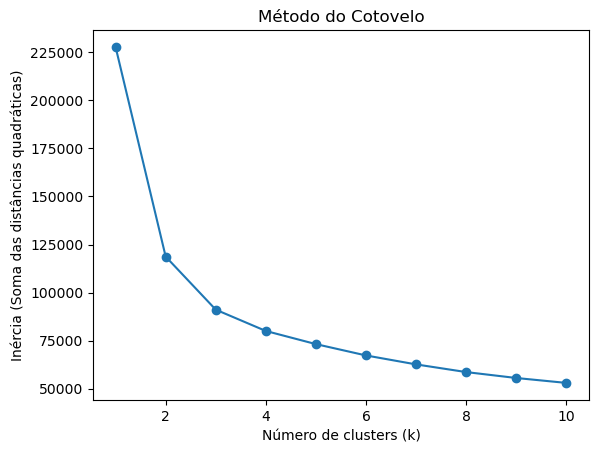

In [5]:
df_notas = df_ifnmg.copy()
notas = df_notas[["NU_NOTA_CN",	"NU_NOTA_CH",	"NU_NOTA_LC", "NU_NOTA_MT"]]

# Remover linhas com NaN nas colunas de notas
notas = notas.dropna()

# Normalizar
scaler = StandardScaler()
notas_normalizadas = scaler.fit_transform(notas)

# Testar diferentes valores de k
inercia = []
K = range(1, 11)  # de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(notas_normalizadas)
    inercia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadráticas)")
plt.title("Método do Cotovelo")
plt.show()

O **método da silhueta** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula o coeficiente de silhueta para cada ponto, que mede o quão próximo ele está de pontos do mesmo cluster em comparação com pontos de outros clusters. Valores de silhueta próximos de 1 indicam que o ponto está bem classificado e valores próximos de 0 indicam sobreposição entre clusters.

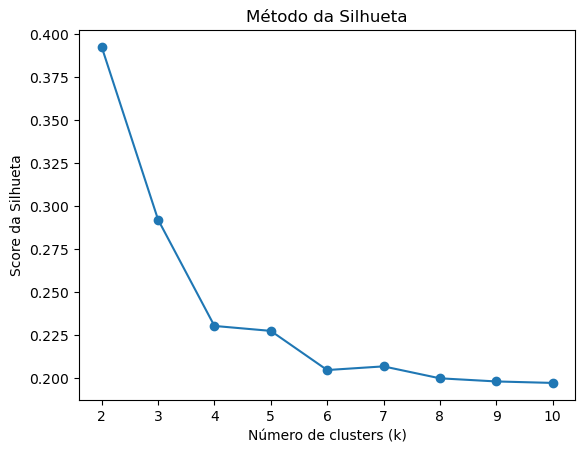

In [6]:
# Calcular os scores de silhueta para diferentes k
silhueta_scores = []
K = range(2, 11)  # começa do 2 porque silhueta não faz sentido para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(notas_normalizadas)
    score = silhouette_score(notas_normalizadas, labels)
    silhueta_scores.append(score)

# Plotar gráfico da silhueta
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta")
plt.show()

## **Avaliação Interna do Agrupamento e Silhueta para todos os clusters**

Para avaliar a qualidade dos agrupamentos obtidos, foram utilizadas duas métricas internas:
(a) a Soma das Distâncias Quadradas aos Centróides (SSQ), que mede a compacidade dos clusters, e
(b) a Razão entre Distância Intracluster e Intercluster (Intra/Inter), que avalia simultaneamente a coesão interna e a separação entre grupos.

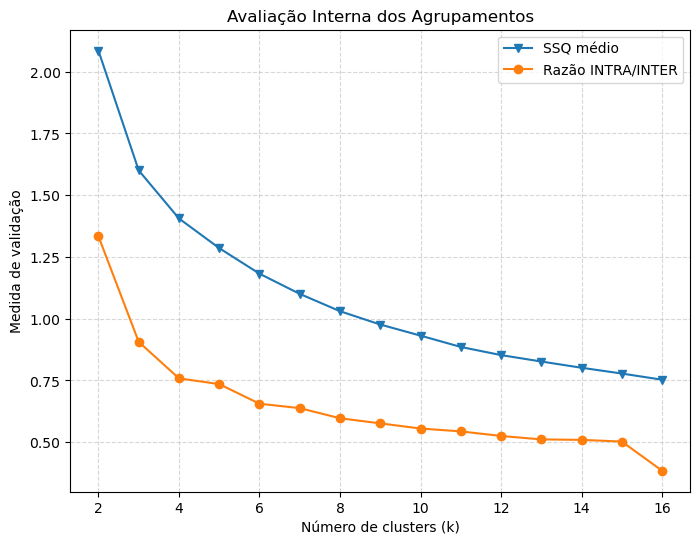


Silhueta global (k=4): 0.2303

Silhueta por cluster:
                                N     media   mediana    desvio    minimo  \
Cluster                                                                     
Desempenho Baixo            13812  0.244700  0.259801  0.132680 -0.023598   
Desempenho Abaixo da Média  19010  0.188134  0.186074  0.104818 -0.008674   
Desempenho Acima da Média   15911  0.202795  0.206554  0.116898 -0.069272   
Desempenho Alto              8213  0.357164  0.402056  0.147521  0.007729   

                              maximo  
Cluster                               
Desempenho Baixo            0.461842  
Desempenho Abaixo da Média  0.427269  
Desempenho Acima da Média   0.453045  
Desempenho Alto             0.560022  


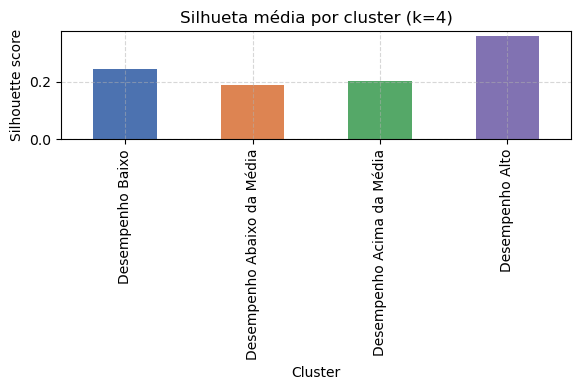

In [7]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

# Normalização das notas
scaler = StandardScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(notas),
    columns=colunas_notas,
    index=notas.index
)


# ============================================================
# 2️⃣ Avaliação Interna (SSQ e INTRA/INTER)
# ============================================================
K = range(2, 17)
ssq_values = []
intra_inter_values = []

for k in K:
    kmeans_tmp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels_tmp = kmeans_tmp.fit_predict(df_norm)

    # SSQ médio
    ssq = kmeans_tmp.inertia_ / len(df_norm)
    ssq_values.append(ssq)

    # Distâncias intra-cluster
    intra_dists = []
    for lbl in np.unique(labels_tmp):
        cluster_points = df_norm[labels_tmp == lbl]
        if len(cluster_points) > 2:
            sample = cluster_points.sample(
                n=min(500, len(cluster_points)),
                random_state=42
            )
            intra = np.mean(pairwise_distances(sample))
        else:
            intra = 0
        intra_dists.append(intra)

    intra_mean = np.mean(intra_dists)

    # Distâncias inter-cluster
    centers = kmeans_tmp.cluster_centers_
    inter_mean = np.mean(pairwise_distances(centers))

    intra_inter_values.append(intra_mean / inter_mean)


# ----------------------------
# Gráfico - Avaliação Interna
# ----------------------------
plt.figure(figsize=(8, 6))
plt.plot(K, ssq_values, 'v-', label='SSQ médio')
plt.plot(K, intra_inter_values, 'o-', label='Razão INTRA/INTER')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Medida de validação")
plt.title("Avaliação Interna dos Agrupamentos")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# ============================================================
# 3️⃣ Modelo Final (k escolhido)
# ============================================================
k_final = 4  # definir conforme critérios internos

kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

labels_final = kmeans_final.fit_predict(df_norm)


# ============================================================
# 4️⃣ Renomeação Semântica dos Clusters
# (independente da numeração original do KMeans)
# ============================================================
centers = kmeans_final.cluster_centers_
order = centers.mean(axis=1).argsort()

old2rank = {old: i for i, old in enumerate(order)}

rank2name = {
    0: "Desempenho Baixo",
    1: "Desempenho Abaixo da Média",
    2: "Desempenho Acima da Média",
    3: "Desempenho Alto"
}


# ============================================================
# 5️⃣ Análise de Silhueta
# ============================================================
sil_global = silhouette_score(df_norm, labels_final)
sil_samples = silhouette_samples(df_norm, labels_final)

df_sil = pd.DataFrame({
    "cluster_id": labels_final,
    "sil": sil_samples
})

df_sil["rank"] = df_sil["cluster_id"].map(old2rank)
df_sil["Cluster"] = df_sil["rank"].map(rank2name)


# ============================================================
# 6️⃣ Resumo Estatístico da Silhueta por Cluster
# ============================================================
resumo = (
    df_sil
    .groupby(["rank", "Cluster"])["sil"]
    .agg(
        N="count",
        media="mean",
        mediana="median",
        desvio="std",
        minimo="min",
        maximo="max"
    )
    .reset_index()
    .sort_values("rank")
    .drop(columns="rank")
    .set_index("Cluster")
)

print(f"\nSilhueta global (k={k_final}): {sil_global:.4f}\n")
print("Silhueta por cluster:")
print(resumo)


# ============================================================
# 7️⃣ Gráfico - Silhueta Média por Cluster
# ============================================================
plt.figure(figsize=(6, 4))

(
    df_sil.groupby("Cluster")["sil"]
    .mean()
    .reindex([
        "Desempenho Baixo",
        "Desempenho Abaixo da Média",
        "Desempenho Acima da Média",
        "Desempenho Alto"
    ])
    .plot(
        kind="bar",
        color=["#4C72B0", "#DD8452", "#55A868", "#8172B2"]
    )
)

plt.title(f"Silhueta média por cluster (k={k_final})")
plt.ylabel("Silhouette score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## **Bisecting K-Means**

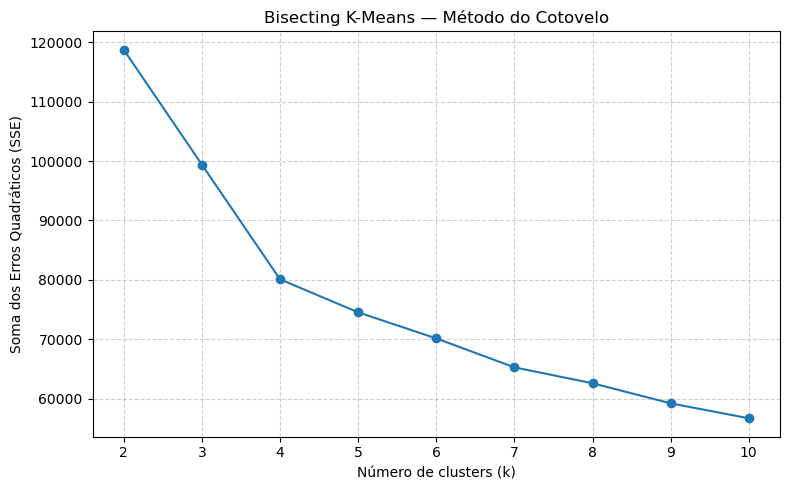

In [8]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

scaler = StandardScaler()
X = scaler.fit_transform(notas)


# ============================================================
# 2️⃣ Função Bisecting K-Means
# ============================================================
def bisecting_kmeans(X, k_final=4, n_init=10, random_state=42):
    """
    Implementação do algoritmo Bisecting K-Means.
    Retorna os labels finais dos clusters.
    """
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)

    while len(clusters) < k_final:
        # Calcula a inércia de cada cluster atual
        inertias = {}
        for cid, X_cluster in clusters.items():
            if len(X_cluster) > 1:
                km = KMeans(n_clusters=1, random_state=random_state)
                km.fit(X_cluster)
                inertias[cid] = km.inertia_
            else:
                inertias[cid] = 0

        # Seleciona o cluster com maior inércia
        cluster_to_split = max(inertias, key=inertias.get)
        X_split = clusters[cluster_to_split]

        # Bissecção do cluster selecionado
        kmeans = KMeans(
            n_clusters=2,
            n_init=n_init,
            random_state=random_state
        )
        split_labels = kmeans.fit_predict(X_split)

        # Novo ID de cluster
        new_cluster_id = max(clusters.keys()) + 1

        # Atualiza os clusters
        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_cluster_id] = X_split[split_labels == 1]

        # Atualiza os labels globais
        idx = np.where(labels == cluster_to_split)[0]
        labels[idx] = np.where(split_labels == 0,
                               cluster_to_split,
                               new_cluster_id)

    return labels


# ============================================================
# 3️⃣ Avaliação Interna — Método do Cotovelo (SSE)
# ============================================================
intervalo_k = range(2, 11)
sse_values = []

for k in intervalo_k:
    labels_bis = bisecting_kmeans(X, k_final=k)

    sse_total = 0
    for lbl in np.unique(labels_bis):
        cluster_points = X[labels_bis == lbl]
        if len(cluster_points) > 1:
            center = cluster_points.mean(axis=0)
            sse_total += np.sum((cluster_points - center) ** 2)

    sse_values.append(sse_total)


# ============================================================
# 4️⃣ Gráfico — Cotovelo Bisecting K-Means
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(intervalo_k, sse_values, marker='o')
plt.title("Bisecting K-Means — Método do Cotovelo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Soma dos Erros Quadráticos (SSE)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## **Matriz de Confusão**

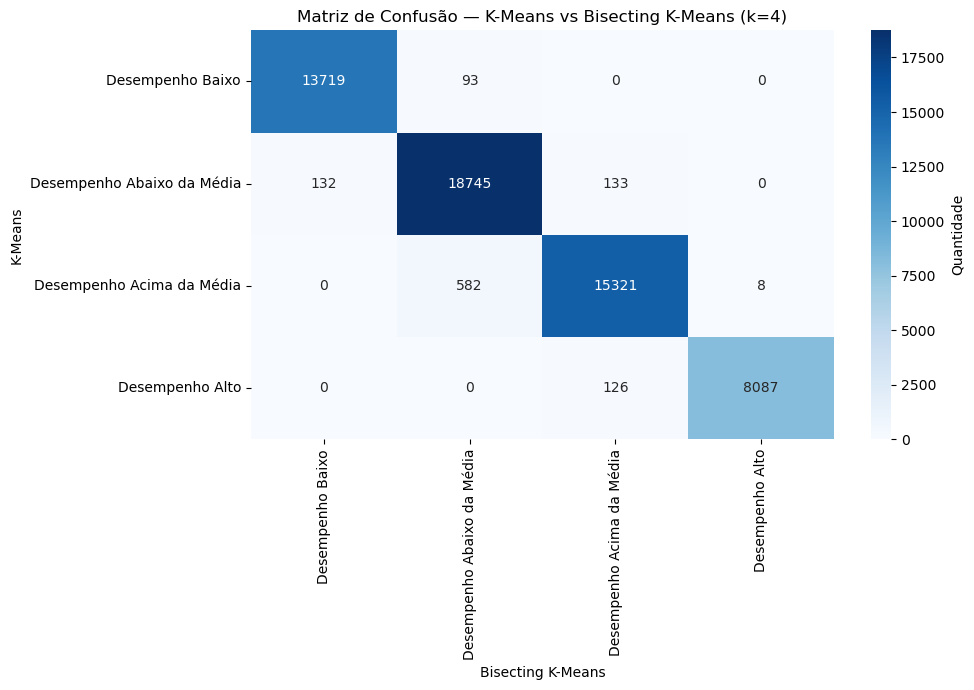

In [9]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

scaler = StandardScaler()
X = scaler.fit_transform(notas)


# ============================================================
# 2️⃣ Função — Bisecting K-Means
# ============================================================
def bisecting_kmeans(X, k_final=4, n_init=10, random_state=42):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)

    while len(clusters) < k_final:
        inertias = {}
        for cid, X_cluster in clusters.items():
            if len(X_cluster) > 1:
                km = KMeans(n_clusters=1, random_state=random_state)
                km.fit(X_cluster)
                inertias[cid] = km.inertia_
            else:
                inertias[cid] = 0

        cluster_to_split = max(inertias, key=inertias.get)
        X_split = clusters[cluster_to_split]

        kmeans = KMeans(
            n_clusters=2,
            n_init=n_init,
            random_state=random_state
        )
        split_labels = kmeans.fit_predict(X_split)

        new_cluster_id = max(clusters.keys()) + 1

        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_cluster_id] = X_split[split_labels == 1]

        idx = np.where(labels == cluster_to_split)[0]
        labels[idx] = np.where(
            split_labels == 0,
            cluster_to_split,
            new_cluster_id
        )

    return labels


# ============================================================
# 3️⃣ Execução dos Modelos
# ============================================================
k_escolhido = 4

# K-Means tradicional
kmeans_final = KMeans(
    n_clusters=k_escolhido,
    random_state=42,
    n_init=10
)
labels_kmeans = kmeans_final.fit_predict(X)

# Bisecting K-Means
labels_bisect = bisecting_kmeans(X, k_final=k_escolhido)


# ============================================================
# 4️⃣ Renomeação Semântica dos Clusters
# (baseada na média das notas de cada cluster)
# ============================================================
def semantic_relabel(X, labels):
    centers = []
    for lbl in np.unique(labels):
        centers.append(X[labels == lbl].mean(axis=0))
    centers = np.array(centers)

    order = centers.mean(axis=1).argsort()
    old2rank = {old: i for i, old in enumerate(order)}

    return np.array([old2rank[l] for l in labels])


labels_kmeans_sem = semantic_relabel(X, labels_kmeans)
labels_bisect_sem = semantic_relabel(X, labels_bisect)

cluster_names = {
    0: "Desempenho Baixo",
    1: "Desempenho Abaixo da Média",
    2: "Desempenho Acima da Média",
    3: "Desempenho Alto"
}


# ============================================================
# 5️⃣ Matriz de Confusão (Semântica)
# ============================================================
cm = confusion_matrix(labels_kmeans_sem, labels_bisect_sem)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[cluster_names[i] for i in range(k_escolhido)],
    yticklabels=[cluster_names[i] for i in range(k_escolhido)],
    cbar_kws={"label": "Quantidade"}
)
plt.xlabel("Bisecting K-Means")
plt.ylabel("K-Means")
plt.title(f"Matriz de Confusão — K-Means vs Bisecting K-Means (k={k_escolhido})")
plt.tight_layout()
plt.show()

## **Análise dos Clusters**


Médias e desvios por cluster (notas padronizadas):

                           NU_NOTA_CN       NU_NOTA_CH       NU_NOTA_LC        \
                                 mean   std       mean   std       mean   std   
Cluster                                                                         
Desempenho Abaixo da Média      -0.41  0.60      -0.19  0.59      -0.14  0.53   
Desempenho Acima da Média        0.45  0.60       0.54  0.54       0.54  0.53   
Desempenho Alto                  1.52  0.60       1.32  0.51       1.29  0.54   
Desempenho Baixo                -0.86  0.64      -1.15  0.64      -1.20  0.68   

                           NU_NOTA_MT        
                                 mean   std  
Cluster                                      
Desempenho Abaixo da Média      -0.43  0.60  
Desempenho Acima da Média        0.41  0.64  
Desempenho Alto                  1.57  0.61  
Desempenho Baixo                -0.82  0.58  


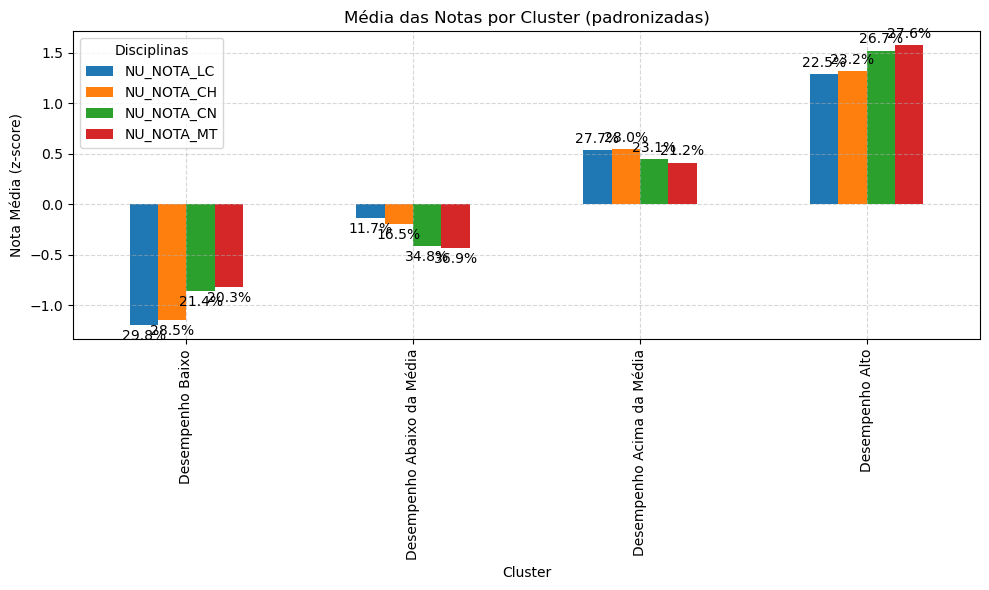

In [10]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

# Normalização (z-score)
scaler = StandardScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(notas),
    index=notas.index,
    columns=colunas_notas
)


# ============================================================
# 2️⃣ K-Means
# ============================================================
k = 4  # definido a partir dos critérios internos
kmeans_final = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
labels_raw = kmeans_final.fit_predict(df_norm)


# ============================================================
# 3️⃣ Renomeação Semântica dos Clusters
# (independente da numeração do algoritmo)
# ============================================================
centers = kmeans_final.cluster_centers_
order = centers.mean(axis=1).argsort()

old2rank = {old: i for i, old in enumerate(order)}

rank2name = {
    0: "Desempenho Baixo",
    1: "Desempenho Abaixo da Média",
    2: "Desempenho Acima da Média",
    3: "Desempenho Alto"
}

df_norm["cluster_id"] = labels_raw
df_norm["Cluster"] = df_norm["cluster_id"].map(old2rank).map(rank2name)


# ============================================================
# 4️⃣ Resumo Estatístico dos Clusters
# ============================================================
resumo_clusters = (
    df_norm
    .groupby("Cluster")[colunas_notas]
    .agg(["mean", "std"])
    .round(2)
)

print("\nMédias e desvios por cluster (notas padronizadas):\n")
print(resumo_clusters)


# ============================================================
# 5️⃣ Gráfico — Médias das Disciplinas por Cluster
# ============================================================
resumo_mean = df_norm.groupby("Cluster")[colunas_notas].mean()

# Ordem lógica dos clusters
ordem_clusters = [
    "Desempenho Baixo",
    "Desempenho Abaixo da Média",
    "Desempenho Acima da Média",
    "Desempenho Alto"
]
resumo_mean = resumo_mean.reindex(ordem_clusters)

# Ordena disciplinas pela média global
ordem_cols = resumo_mean.mean(axis=0).sort_values().index
resumo_sorted = resumo_mean[ordem_cols]

# Percentual de contribuição de cada disciplina dentro do cluster
percent_df = resumo_sorted.div(resumo_sorted.sum(axis=1), axis=0) * 100


# ----------------------------
# Gráfico
# ----------------------------
ax = resumo_sorted.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Média das Notas por Cluster (padronizadas)")
plt.xlabel("Cluster")
plt.ylabel("Nota Média (z-score)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Disciplinas")

# Percentuais sobre as barras
for i, container in enumerate(ax.containers):
    col = resumo_sorted.columns[i]
    labels = [
        f"{percent_df.loc[cluster, col]:.1f}%"
        for cluster in resumo_sorted.index
    ]
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()


O cluster “Desempenho Baixo” concentra os estudantes com os piores resultados, apresentando médias significativamente abaixo da média em todas as disciplinas. As maiores defasagens são observadas em Ciências Humanas e Matemática, indicando um grupo que demanda maior atenção pedagógica, com ações estruturadas de reforço e acompanhamento contínuo.

O cluster “Desempenho Abaixo da Média” reúne alunos que, embora não apresentem desempenho tão crítico quanto o grupo anterior, ainda permanecem abaixo da média geral em todas as áreas. Destacam-se as dificuldades mais acentuadas em Ciências da Natureza e Matemática, sugerindo fragilidades específicas nessas disciplinas.

O cluster “Desempenho Acima da Média” representa estudantes com desempenho moderadamente superior à média, apresentando z-scores positivos em todas as disciplinas. Trata-se de um grupo relativamente equilibrado, sem grandes assimetrias entre as áreas do conhecimento, indicando consistência no desempenho acadêmico.

Por fim, o cluster “Desempenho Alto” agrupa os estudantes com os melhores resultados do conjunto, exibindo médias bem acima da média em todas as disciplinas. Os maiores destaques concentram-se em Matemática e Ciências da Natureza, áreas nas quais os z-scores atingem os valores mais elevados, caracterizando um perfil de alto rendimento acadêmico.

De forma geral, a segmentação obtida evidencia perfis distintos de desempenho escolar, permitindo compreender melhor as heterogeneidades presentes na população analisada. Esses resultados oferecem subsídios importantes para a formulação de estratégias pedagógicas diferenciadas, possibilitando intervenções mais direcionadas tanto para estudantes em situação de maior vulnerabilidade quanto para aqueles com elevado desempenho.

## **Análise dos clusters com as notas sem normalizar**

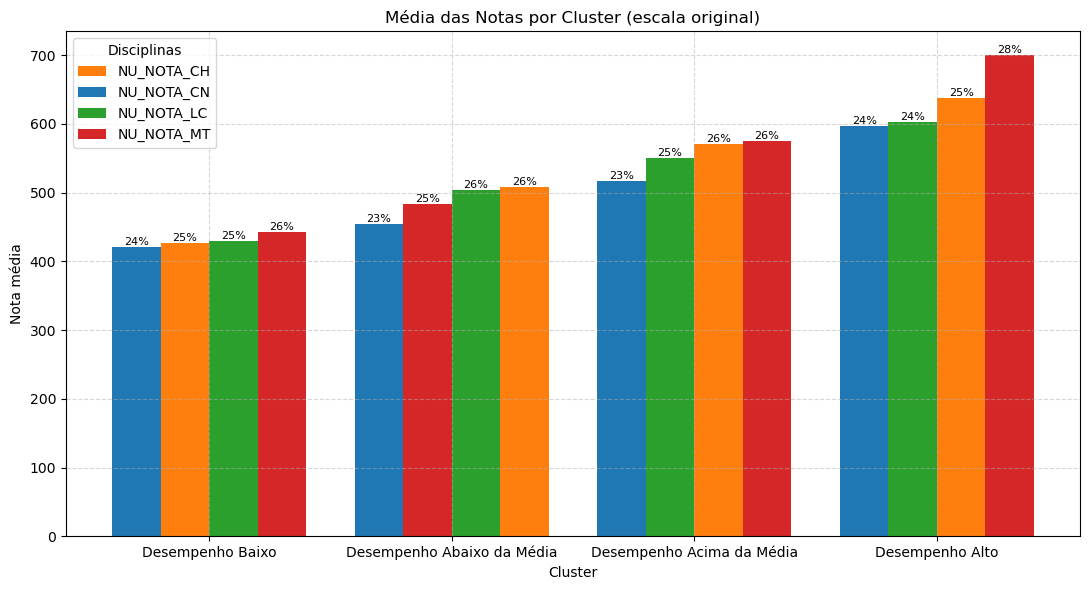

In [11]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

# Normalização apenas para o K-Means
scaler = StandardScaler()
X = scaler.fit_transform(notas)


# ============================================================
# 2️⃣ K-Means
# ============================================================
k = 4
kmeans_final = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
labels_raw = kmeans_final.fit_predict(X)


# ============================================================
# 3️⃣ Renomeação Semântica dos Clusters
# (baseada na média das notas NORMALIZADAS)
# ============================================================
centers = kmeans_final.cluster_centers_
order = centers.mean(axis=1).argsort()

old2rank = {old: i for i, old in enumerate(order)}

rank2name = {
    0: "Desempenho Baixo",
    1: "Desempenho Abaixo da Média",
    2: "Desempenho Acima da Média",
    3: "Desempenho Alto"
}


# ============================================================
# 4️⃣ Junta labels semânticos às notas ORIGINAIS
# ============================================================
notas_orig = notas.copy()
notas_orig["cluster_id"] = labels_raw
notas_orig["Cluster"] = notas_orig["cluster_id"].map(old2rank).map(rank2name)


# ============================================================
# 5️⃣ Média das Notas por Cluster (escala original)
# ============================================================
resumo_mean = (
    notas_orig
    .groupby("Cluster")[colunas_notas]
    .mean()
    .reindex([
        "Desempenho Baixo",
        "Desempenho Abaixo da Média",
        "Desempenho Acima da Média",
        "Desempenho Alto"
    ])
)


# ============================================================
# 6️⃣ Dados em formato longo + percentuais
# ============================================================
long = (
    resumo_mean
    .reset_index()
    .melt(id_vars="Cluster",
          var_name="Disciplina",
          value_name="Valor")
)

# Percentual interno (soma = 100% por cluster)
long["Percent"] = (
    long.groupby("Cluster")["Valor"]
        .transform(lambda s: s / s.sum() * 100)
)

# Ranking das disciplinas dentro de cada cluster
long["Rank"] = (
    long.groupby("Cluster")["Valor"]
        .rank(method="first", ascending=True)
        .astype(int)
)


# ============================================================
# 7️⃣ Preparação visual
# ============================================================
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
disciplinas = long["Disciplina"].unique().tolist()
cores = {d: palette[i % len(palette)] for i, d in enumerate(disciplinas)}

clusters = resumo_mean.index.tolist()
n_vars = len(disciplinas)
width = 0.8 / n_vars

centros = {c: i for i, c in enumerate(clusters)}
offsets = {
    r: (r - (n_vars + 1) / 2) * width
    for r in range(1, n_vars + 1)
}

long["x"] = (
    long["Cluster"].map(centros) +
    long["Rank"].map(offsets)
)


# ============================================================
# 8️⃣ Gráfico final
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))
bar_info = {}

for disc, sub in long.groupby("Disciplina"):
    bars = ax.bar(
        sub["x"],
        sub["Valor"],
        width=width,
        label=disc,
        color=cores[disc]
    )
    bar_info[disc] = (bars, sub)

# Percentuais sobre as barras
for disc, (bars, sub) in bar_info.items():
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{row['Percent']:.0f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(list(centros.values()))
ax.set_xticklabels(clusters)

ax.legend(title="Disciplinas")
ax.set_title("Média das Notas por Cluster (escala original)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Nota média")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## **Cenário do desempenho dos inscritos em cada um dos anos contemplados nas bases**

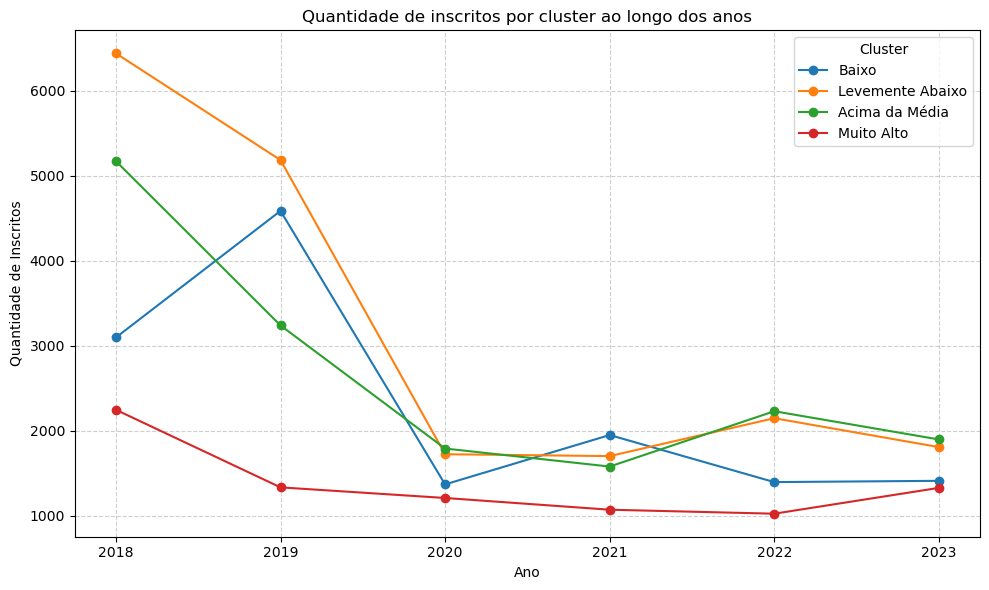

In [12]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
colunas_notas = [
    "NU_ANO",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = df_ifnmg[colunas_notas].dropna().copy()

# Apenas as notas (sem criar média)
X = notas[
    ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
].values


# ============================================================
# 2️⃣ Normalização (somente para clusterização)
# ============================================================
scaler = StandardScaler()
Xz = scaler.fit_transform(X)


# ============================================================
# 3️⃣ K-Means
# ============================================================
k = 4
kmeans_final = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels_raw = kmeans_final.fit_predict(Xz)


# ============================================================
# 4️⃣ Renomeação Semântica dos Clusters
# (baseada nos centróides normalizados)
# ============================================================
centers = kmeans_final.cluster_centers_
centers_mean = centers.mean(axis=1)

order = np.argsort(centers_mean)  # do pior ao melhor
old_to_rank = {old: rank for rank, old in enumerate(order)}

rank_to_name = {
    0: "Baixo",
    1: "Levemente Abaixo",
    2: "Acima da Média",
    3: "Muito Alto"
}

notas["cluster_id"] = labels_raw
notas["Cluster"] = notas["cluster_id"].map(old_to_rank).map(rank_to_name)


# ============================================================
# 5️⃣ Contagem por Ano e Cluster
# ============================================================
contagem = (
    notas
    .groupby(["NU_ANO", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)


# ============================================================
# 6️⃣ Gráfico — Evolução Temporal
# ============================================================
plt.figure(figsize=(10, 6))

ordem_clusters = [
    "Baixo",
    "Levemente Abaixo",
    "Acima da Média",
    "Muito Alto"
]

for nome in ordem_clusters:
    df_plot = contagem[contagem["Cluster"] == nome]
    if not df_plot.empty:
        plt.plot(
            df_plot["NU_ANO"],
            df_plot["Quantidade"],
            marker="o",
            label=nome
        )

plt.title("Quantidade de inscritos por cluster ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Inscritos")
plt.legend(title="Cluster")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## **Quantidade de inscritos por grupo**

In [13]:
# ============================================================
# 1️⃣ Contagem por Cluster (ordem semântica)
# ============================================================
ordem_clusters = [
    "Baixo",
    "Levemente Abaixo",
    "Acima da Média",
    "Muito Alto"
]

tabela_clusters = (
    notas["Cluster"]
    .value_counts()
    .reindex(ordem_clusters)
    .reset_index()
)

tabela_clusters.columns = ["Grupo", "Quantidade"]


# ============================================================
# 2️⃣ Cálculo de total e percentual
# ============================================================
total = int(tabela_clusters["Quantidade"].sum())

tabela_clusters["Porcentagem"] = (
    tabela_clusters["Quantidade"] / total * 100
).round(1)


# ============================================================
# 3️⃣ Linha Total
# ============================================================
linha_total = pd.DataFrame({
    "Grupo": ["Total"],
    "Quantidade": [total],
    "Porcentagem": [100.0]
})

tabela_final = pd.concat(
    [tabela_clusters, linha_total],
    ignore_index=True
)


# ============================================================
# 4️⃣ Formatação apenas para exibição
# (não altera os valores numéricos originais)
# ============================================================
tabela_final_fmt = tabela_final.copy()

tabela_final_fmt["Quantidade"] = (
    tabela_final_fmt["Quantidade"]
    .map(lambda x: f"{int(x):,}".replace(",", "."))
)

tabela_final_fmt["Porcentagem"] = (
    tabela_final_fmt["Porcentagem"]
    .map(lambda x: f"{x:.0f}%")
)


# ============================================================
# 5️⃣ Exibição
# ============================================================
print("\nDistribuição dos participantes por cluster:\n")
print(tabela_final_fmt)


Distribuição dos participantes por cluster:

              Grupo Quantidade Porcentagem
0             Baixo     13.812         24%
1  Levemente Abaixo     19.010         33%
2    Acima da Média     15.911         28%
3        Muito Alto      8.213         14%
4             Total     56.946        100%


## **Quantidade de inscritos por grupo entre 2018 e 2023**

In [14]:
# ============================================================
# 1️⃣ Contagem por Ano e Cluster
# ============================================================
contagem = (
    notas
    .groupby(["NU_ANO", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)


# ============================================================
# 2️⃣ Tabela em formato largo (pivot)
# ============================================================
ordem_clusters = [
    "Baixo",
    "Levemente Abaixo",
    "Acima da Média",
    "Muito Alto"
]

tabela = (
    contagem
    .pivot(index="NU_ANO", columns="Cluster", values="Quantidade")
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
    .sort_index()
)


# ============================================================
# 3️⃣ Total por ano
# ============================================================
tabela["Total"] = tabela.sum(axis=1)


# ============================================================
# 4️⃣ Formatação apenas para exibição
# (mantém a tabela original intacta)
# ============================================================
tabela_fmt = tabela.copy()

tabela_fmt = tabela_fmt.apply(
    lambda col: col.map(
        lambda x: f"{int(x):,}".replace(",", ".")
    )
)


# ============================================================
# 5️⃣ Exibição
# ============================================================
print("\nDistribuição de inscritos por cluster e por ano:\n")
print(tabela_fmt)


Distribuição de inscritos por cluster e por ano:

Cluster  Baixo Levemente Abaixo Acima da Média Muito Alto   Total
NU_ANO                                                           
2018     3.098            6.442          5.173      2.247  16.960
2019     4.588            5.186          3.240      1.334  14.348
2020     1.369            1.724          1.791      1.209   6.093
2021     1.950            1.702          1.579      1.071   6.302
2022     1.396            2.148          2.230      1.024   6.798
2023     1.411            1.808          1.898      1.328   6.445


## **Média e Desvio Padrão das notas por grupo entre 2018 e 2023.**

In [15]:
# ============================================================
# 1️⃣ Configurações
# ============================================================
cols_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

ordem_clusters = [
    "Baixo",
    "Levemente Abaixo",
    "Acima da Média",
    "Muito Alto"
]


# ============================================================
# 2️⃣ Agregação: média por ano e cluster
# ============================================================
agg = (
    notas[notas["Cluster"].isin(ordem_clusters)]
    .groupby(["NU_ANO", "Cluster"])[cols_notas]
    .mean()
    .round(1)
    .reset_index()
)


# ============================================================
# 3️⃣ Formato largo (pivot)
# ============================================================
wide = (
    agg
    .pivot(index="NU_ANO", columns="Cluster", values=cols_notas)
    .reindex(
        columns=pd.MultiIndex.from_product(
            [cols_notas, ordem_clusters]
        )
    )
    .sort_index()
)


# ============================================================
# 4️⃣ Renomeação das colunas (disciplinas)
# ============================================================
abrevs = {
    "NU_NOTA_CN": "Ciên. Nat.",
    "NU_NOTA_CH": "Ciên. Hum.",
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática"
}

def rotulo(col):
    disciplina, cluster = col
    return f"{abrevs[disciplina]} - {cluster}"

wide.columns = [rotulo(c) for c in wide.columns]
wide.index.name = "Ano"


# ============================================================
# 5️⃣ Formatação apenas para exibição
# (troca ponto por vírgula)
# ============================================================
tabela_fmt = (
    wide
    .copy()
    .applymap(lambda x: "" if pd.isna(x) else str(x).replace(".", ","))
)


# ============================================================
# 6️⃣ Exibição
# ============================================================
print("\nMédia das notas por disciplina, ano e cluster:\n")
print(tabela_fmt)


Média das notas por disciplina, ano e cluster:

     Ciên. Nat. - Baixo Ciên. Nat. - Levemente Abaixo  \
Ano                                                     
2018              429,8                         451,8   
2019              409,0                         446,2   
2020              420,5                         453,8   
2021              423,4                         461,4   
2022              435,4                         460,8   
2023              416,9                         466,8   

     Ciên. Nat. - Acima da Média Ciên. Nat. - Muito Alto Ciên. Hum. - Baixo  \
Ano                                                                           
2018                       509,5                   594,5              459,2   
2019                       519,2                   590,7              414,9   
2020                       525,6                   600,2              407,0   
2021                       524,3                   605,1              422,4   
2022                

C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_28048\573494826.py:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: "" if pd.isna(x) else str(x).replace(".", ","))


## **Quantidade de inscritos por grupo para cada tipo de escola**

C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_28048\1760857364.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ifnmg["TP_ESCOLA_PAD"] = df_ifnmg.apply(padronizar_tp_escola, axis=1)



📊 Quantidade — Ano × Escola × Cluster:



Cluster               Baixo  Levemente Abaixo  Acima da Média  Muito Alto
NU_ANO TP_ESCOLA_PAD                                                     
2018   Não respondeu     17               102             262         348
       Pública         3022              6083            4330         947
       Privada           55               253             577         951
       Exterior           4                 4               4           1
2019   Não respondeu      0                 0               0           0
       Pública         4540              5078            2987         968
       Privada           48               108             253         366
       Exterior           0                 0               0           0
2020   Não respondeu      0                 0               0           0
       Pública         1327              1615            1543         758
       Privada           42               109             248         451
       Exterior           0                 0               0           0
2021   Não respondeu      0                 0               0           0
       Pública         1880              1558            1285         700
       Privada           70               144             294         371
       Exterior           0                 0               0           0
2022   Não respondeu      0                 0               0           0
       Pública         1350              1999            1856         645
       Privada           46               149             374         379
       Exterior           0                 0               0           0
2023   Não respondeu      0                 0               0           0
       Pública         1359              1659            1569         759
       Privada           52               149             329         569
       Exterior           0                 0               0           0


📈 Percentual — Ano × Escola × Cluster:



Cluster               Baixo  Levemente Abaixo  Acima da Média  Muito Alto
NU_ANO TP_ESCOLA_PAD                                                     
2018   Não respondeu    2.3              14.0            35.9        47.7
       Pública         21.0              42.3            30.1         6.6
       Privada          3.0              13.8            31.4        51.8
       Exterior        30.8              30.8            30.8         7.7
2019   Não respondeu    NaN               NaN             NaN         NaN
       Pública         33.4              37.4            22.0         7.1
       Privada          6.2              13.9            32.6        47.2
       Exterior         NaN               NaN             NaN         NaN
2020   Não respondeu    NaN               NaN             NaN         NaN
       Pública         25.3              30.8            29.4        14.5
       Privada          4.9              12.8            29.2        53.1
       Exterior         NaN               NaN             NaN         NaN
2021   Não respondeu    NaN               NaN             NaN         NaN
       Pública         34.7              28.7            23.7        12.9
       Privada          8.0              16.4            33.4        42.2
       Exterior         NaN               NaN             NaN         NaN
2022   Não respondeu    NaN               NaN             NaN         NaN
       Pública         23.1              34.2            31.7        11.0
       Privada          4.9              15.7            39.5        40.0
       Exterior         NaN               NaN             NaN         NaN
2023   Não respondeu    NaN               NaN             NaN         NaN
       Pública         25.4              31.0            29.3        14.2
       Privada          4.7              13.6            29.9        51.8
       Exterior         NaN               NaN             NaN         NaN

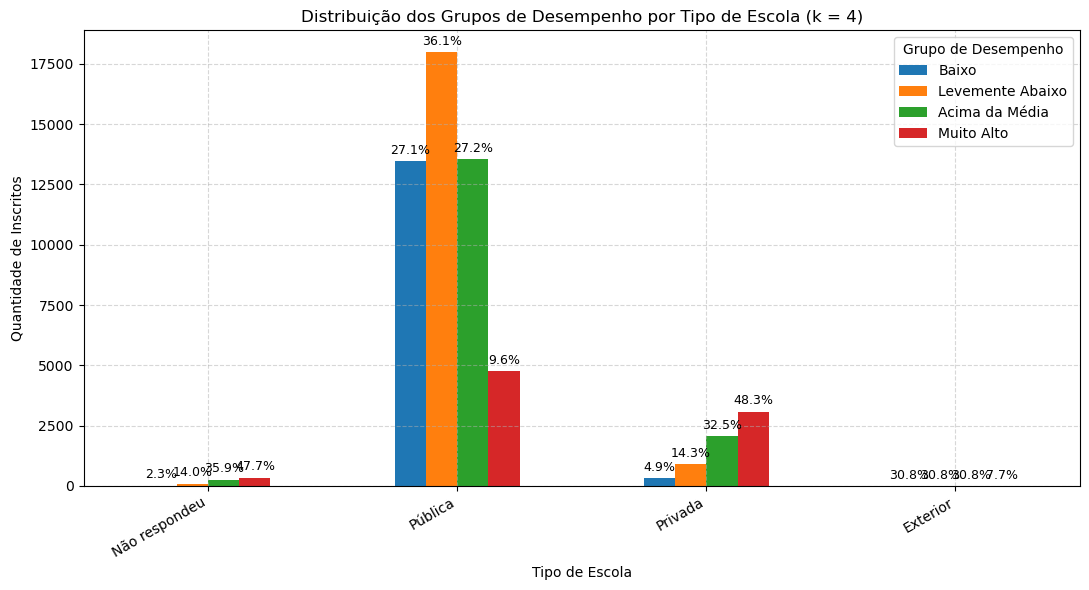


📊 Resumo Geral dos Grupos de Desempenho:



,Quantidade,Percentual (%)
Cluster,,
Baixo,13812,24.3
Levemente Abaixo,19010,33.4
Acima da Média,15911,27.9
Muito Alto,8213,14.4


In [16]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ============================================================
# 1️⃣ PADRONIZAÇÃO TP_ESCOLA POR ANO
# ============================================================

def padronizar_tp_escola(row):
    ano = row["NU_ANO"]
    valor = row["TP_ESCOLA"]

    if pd.isna(valor):
        return "Não respondeu"

    # 2018
    if ano == 2018:
        mapa = {
            1: "Não respondeu",
            2: "Pública",
            3: "Exterior",
            4: "Privada"
        }

    # 2019 e 2020
    elif ano in [2019, 2020]:
        mapa = {
            1: "Não respondeu",
            2: "Pública",
            3: "Privada",
            4: "Exterior"
        }

    # 2021–2023
    elif ano in [2021, 2022, 2023]:
        mapa = {
            1: "Não respondeu",
            2: "Pública",
            3: "Privada"
        }

    else:
        return "Não respondeu"

    return mapa.get(valor, "Não respondeu")


df_ifnmg["TP_ESCOLA_PAD"] = df_ifnmg.apply(padronizar_tp_escola, axis=1)


# ============================================================
# 2️⃣ PREPARAÇÃO DOS DADOS
# ============================================================

cols = [
    "NU_ANO",
    "TP_ESCOLA_PAD",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

base = df_ifnmg[cols].dropna().copy()

ordem_escola = ["Não respondeu", "Pública", "Privada", "Exterior"]
ordem_cluster = ["Baixo", "Levemente Abaixo", "Acima da Média", "Muito Alto"]

base["TP_ESCOLA_PAD"] = pd.Categorical(
    base["TP_ESCOLA_PAD"],
    categories=ordem_escola,
    ordered=True
)


# ============================================================
# 3️⃣ CLUSTERIZAÇÃO (k = 4)
# ============================================================

X = base[["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]].values

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_raw = kmeans.fit_predict(Xz)

# Ordenação semântica
centers_mean = kmeans.cluster_centers_.mean(axis=1)
ordem_media = np.argsort(centers_mean)

old_to_rank = {old: rank for rank, old in enumerate(ordem_media)}

rank_to_name = {
    0: "Baixo",
    1: "Levemente Abaixo",
    2: "Acima da Média",
    3: "Muito Alto"
}

base["Cluster"] = (
    pd.Series(labels_raw, index=base.index)
    .map(old_to_rank)
    .map(rank_to_name)
)

base["Cluster"] = pd.Categorical(
    base["Cluster"],
    categories=ordem_cluster,
    ordered=True
)


# ============================================================
# 4️⃣ TABELA ANO × ESCOLA × CLUSTER (Quantidade)
# ============================================================

tabela_ano = (
    base
    .groupby(["NU_ANO", "TP_ESCOLA_PAD", "Cluster"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ordem_cluster)
    .sort_index()
)

print("\n📊 Quantidade — Ano × Escola × Cluster:\n")
display(tabela_ano)


# ============================================================
# 5️⃣ TABELA PERCENTUAL
# ============================================================

tabela_percent = (
    tabela_ano
    .div(tabela_ano.sum(axis=1), axis=0)
    .multiply(100)
    .round(1)
)

print("\n📈 Percentual — Ano × Escola × Cluster:\n")
display(tabela_percent)


# ============================================================
# 6️⃣ TABELA GERAL POR TIPO DE ESCOLA (Agregado)
# ============================================================

tabela_geral = (
    base
    .groupby(["TP_ESCOLA_PAD", "Cluster"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=ordem_escola)
    .reindex(columns=ordem_cluster)
)

percent_geral = (
    tabela_geral
    .div(tabela_geral.sum(axis=1), axis=0)
    .multiply(100)
    .round(1)
)


# ============================================================
# 7️⃣ GRÁFICO GERAL
# ============================================================

ax = tabela_geral.plot(kind="bar", figsize=(11, 6))

ax.set_title("Distribuição dos Grupos de Desempenho por Tipo de Escola (k = 4)")
ax.set_xlabel("Tipo de Escola")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo de Desempenho")
ax.grid(True, linestyle="--", alpha=0.5)

plt.xticks(rotation=30, ha="right")

for i, container in enumerate(ax.containers):
    col = tabela_geral.columns[i]
    labels = [f"{v:.1f}%" for v in percent_geral[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# 8️⃣ RESUMO TOTAL DOS CLUSTERS
# ============================================================

tabela_total = (
    tabela_geral
    .sum()
    .to_frame(name="Quantidade")
)

tabela_total["Percentual (%)"] = (
    tabela_total["Quantidade"] /
    tabela_total["Quantidade"].sum() * 100
).round(1)

print("\n📊 Resumo Geral dos Grupos de Desempenho:\n")
display(tabela_total)


A análise da distribuição dos grupos de desempenho por tipo de escola revela diferenças estruturais importantes entre os perfis educacionais, evidenciando a associação entre contexto escolar e rendimento acadêmico.

Entre os estudantes de escolas públicas, observa-se maior concentração nos níveis intermediários e inferiores de desempenho. Cerca de 36,1% encontram-se no grupo Levemente Abaixo e 27,1% no grupo Baixo, totalizando aproximadamente 63% com desempenho abaixo da média geral. Por outro lado, 27,2% situam-se no grupo Acima da Média e apenas 9,6% no grupo Muito Alto, indicando que, embora exista uma parcela de alto rendimento, ela é proporcionalmente menor nesse segmento.

Nas escolas privadas, o padrão é significativamente distinto. A maior concentração está nos grupos superiores: 48,3% dos estudantes classificam-se como Muito Alto e 32,5% como Acima da Média, somando mais de 80% acima da média geral. Os grupos de menor desempenho representam parcelas reduzidas, com 4,9% no grupo Baixo e 14,3% no grupo Levemente Abaixo, evidenciando menor incidência de desempenho insatisfatório nesse contexto.

No caso dos estudantes provenientes do exterior, observa-se uma distribuição mais equilibrada entre os três primeiros grupos, com aproximadamente 30,8% em Baixo, 30,8% em Levemente Abaixo e 30,8% em Acima da Média, enquanto 7,7% situam-se no grupo Muito Alto. Esse padrão sugere heterogeneidade de desempenho nesse segmento, diferentemente do perfil mais concentrado observado nas escolas privadas.

Por fim, entre os participantes que não informaram o tipo de escola, verifica-se predominância nos grupos superiores, com 47,7% no grupo Muito Alto e 35,9% no grupo Acima da Média. Os grupos de menor desempenho apresentam percentuais mais reduzidos (2,3% em Baixo e 14,0% em Levemente Abaixo). Contudo, por se tratar de um grupo proporcionalmente menor, recomenda-se cautela na interpretação desses resultados.

Em síntese, os dados indicam forte associação entre tipo de escola e desempenho acadêmico: enquanto as escolas privadas concentram a maior proporção de estudantes nos níveis mais elevados de desempenho, as escolas públicas apresentam maior concentração nos níveis inferiores e intermediários, evidenciando desigualdades estruturais no rendimento educacional.


## **Quantidade de inscritos por grupo para cada gênero**


Tabela (Sexo × Cluster) – valores absolutos:

Cluster    Baixo  Levemente Abaixo  Acima da Média  Muito Alto  Total
Feminino    8923             12528            9112        3960  34523
Masculino   4889              6482            6799        4253  22423
Total      13812             19010           15911        8213  56946


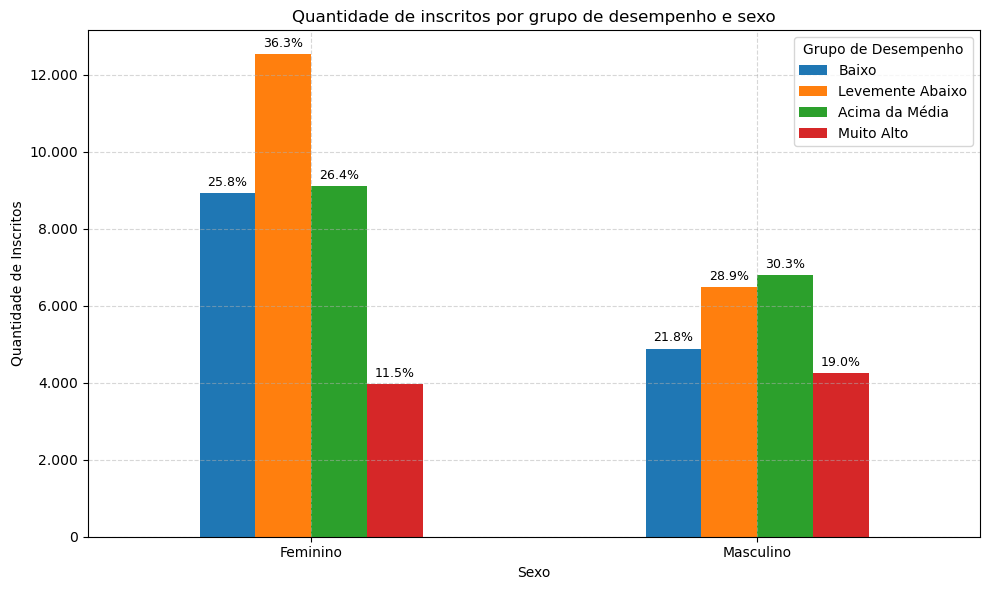


Tabela (Ano × Sexo × Cluster) – valores absolutos:

Cluster           Baixo  Levemente Abaixo  Acima da Média  Muito Alto
NU_ANO TP_SEXO                                                       
2018   Feminino    2038              4285            3113        1114
       Masculino   1060              2157            2060        1133
2019   Feminino    2984              3472            1835         621
       Masculino   1604              1714            1405         713
2020   Feminino     920              1105             970         608
       Masculino    449               619             821         601
2021   Feminino    1246              1061             902         508
       Masculino    704               641             677         563
2022   Feminino     858              1401            1238         489
       Masculino    538               747             992         535
2023   Feminino     877              1204            1054         620
       Masculino    534              

In [18]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
colunas_notas = [
    "NU_ANO",
    "TP_SEXO",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = df_ifnmg[colunas_notas].dropna().copy()

# ============================================================
# 2️⃣ Clusterização (caso ainda não exista a coluna Cluster)
# ============================================================
if "Cluster" not in notas.columns:

    X = notas[
        ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
    ].values

    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    k = 4
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_raw = km.fit_predict(Xz)

    centers = km.cluster_centers_
    centers_mean = centers.mean(axis=1)
    order = np.argsort(centers_mean)

    old2rank = {old: r for r, old in enumerate(order)}
    rank2name = {
        0: "Baixo",
        1: "Levemente Abaixo",
        2: "Acima da Média",
        3: "Muito Alto"
    }

    notas["cluster_id"] = labels_raw
    notas["Cluster"] = notas["cluster_id"].map(old2rank).map(rank2name)

# Ordem fixa dos clusters
ordem_clusters = [
    "Baixo",
    "Levemente Abaixo",
    "Acima da Média",
    "Muito Alto"
]

# ============================================================
# 3️⃣ Contagem por Sexo e Cluster
# ============================================================
contagem_sexo = (
    notas
    .groupby(["TP_SEXO", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)

tabela = (
    contagem_sexo
    .pivot_table(
        index="TP_SEXO",
        columns="Cluster",
        values="Quantidade",
        aggfunc="sum",
        observed=True
    )
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)

# ============================================================
# 4️⃣ Rótulos de Sexo
# ============================================================
def rotulo_sexo(v):
    return {
        0: "Feminino",
        1: "Masculino",
        "0": "Feminino",
        "1": "Masculino",
        "F": "Feminino",
        "M": "Masculino"
    }.get(v, str(v))

tabela.index = [rotulo_sexo(i) for i in tabela.index]

# ============================================================
# 5️⃣ Tabela com Totais
# ============================================================
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)

print("\nTabela (Sexo × Cluster) – valores absolutos:\n")
print(tabela_tot)

# ============================================================
# 6️⃣ Percentuais por Sexo
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

# ============================================================
# 7️⃣ Gráfico — Distribuição por Sexo
# ============================================================
ax = tabela.plot(kind="bar", figsize=(10, 6))

ax.set_title("Quantidade de inscritos por grupo de desempenho e sexo")
ax.set_xlabel("Sexo")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo de Desempenho")
ax.set_xticklabels(tabela.index, rotation=0)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

ax.grid(True, linestyle="--", alpha=0.5)

for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# 8️⃣ 🔎 TABELA ANO × SEXO × CLUSTER
# ============================================================

contagem_ano = (
    notas
    .groupby(["NU_ANO", "TP_SEXO", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)

tabela_ano = (
    contagem_ano
    .pivot_table(
        index=["NU_ANO", "TP_SEXO"],
        columns="Cluster",
        values="Quantidade",
        aggfunc="sum",
        observed=True
    )
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)

# Ajustar rótulos de sexo
tabela_ano = tabela_ano.reset_index()
tabela_ano["TP_SEXO"] = tabela_ano["TP_SEXO"].apply(rotulo_sexo)
tabela_ano = tabela_ano.set_index(["NU_ANO", "TP_SEXO"])

print("\nTabela (Ano × Sexo × Cluster) – valores absolutos:\n")
print(tabela_ano)

# ============================================================
# 9️⃣ Percentual por Ano × Sexo
# ============================================================

percent_ano = (
    tabela_ano
    .div(tabela_ano.sum(axis=1), axis=0)
    * 100
).round(1)

print("\nTabela (Ano × Sexo × Cluster) – Percentual:\n")
print(percent_ano)


Entre os participantes do gênero feminino, observa-se uma distribuição mais concentrada nos grupos Levemente Abaixo (36,3%) e Acima da Média (26,4%). Já o grupo Baixo representa 25,8% das estudantes, enquanto 11,5% alcançam o grupo Muito Alto.
Esse padrão sugere que o desempenho das mulheres tende a se concentrar nos níveis intermediários, com presença relevante nos grupos de rendimento acima da média, embora ainda limitada no grupo de excelência (Muito Alto).

Por outro lado, entre os participantes do gênero masculino, há uma maior presença nos níveis superiores: 30,3% estão no grupo Acima da Média e 19,0% no Muito Alto, totalizando quase metade dos homens (49,3%) com desempenho acima da média.
Nos níveis inferiores, 28,9% encontram-se no grupo Levemente Abaixo e 21,8% no grupo Baixo.

De forma geral, o gráfico evidencia que os homens apresentam uma leve vantagem nos grupos de maior desempenho, enquanto as mulheres se destacam nos níveis intermediários, especialmente no grupo Levemente Abaixo.
Essa diferença pode refletir variações de perfil de estudo, autoconfiança em áreas específicas das provas ou disparidades no acesso a recursos e estratégias de aprendizagem.

Em síntese, os resultados indicam que, embora o desempenho feminino se concentre em torno da média, o grupo masculino mostra maior representatividade nos níveis mais altos, o que sugere uma assimetria moderada de desempenho entre os gêneros.

## **Quantidade de inscritos por grupo para cada cor/raça**


Tabela Raça/Cor × Cluster (valores absolutos):

Cluster        Baixo  Levemente Abaixo  Acima da Média  Muito Alto  Total
Não declarado    188               245             235         162    830
Branca          2384              3819            4213        3186  13602
Preta           2104              2871            2012         685   7672
Parda           8693             11466            9103        4040  33302
Amarela          316               501             298         133   1248
Indígena         127               108              50           7    292
Total          13812             19010           15911        8213  56946


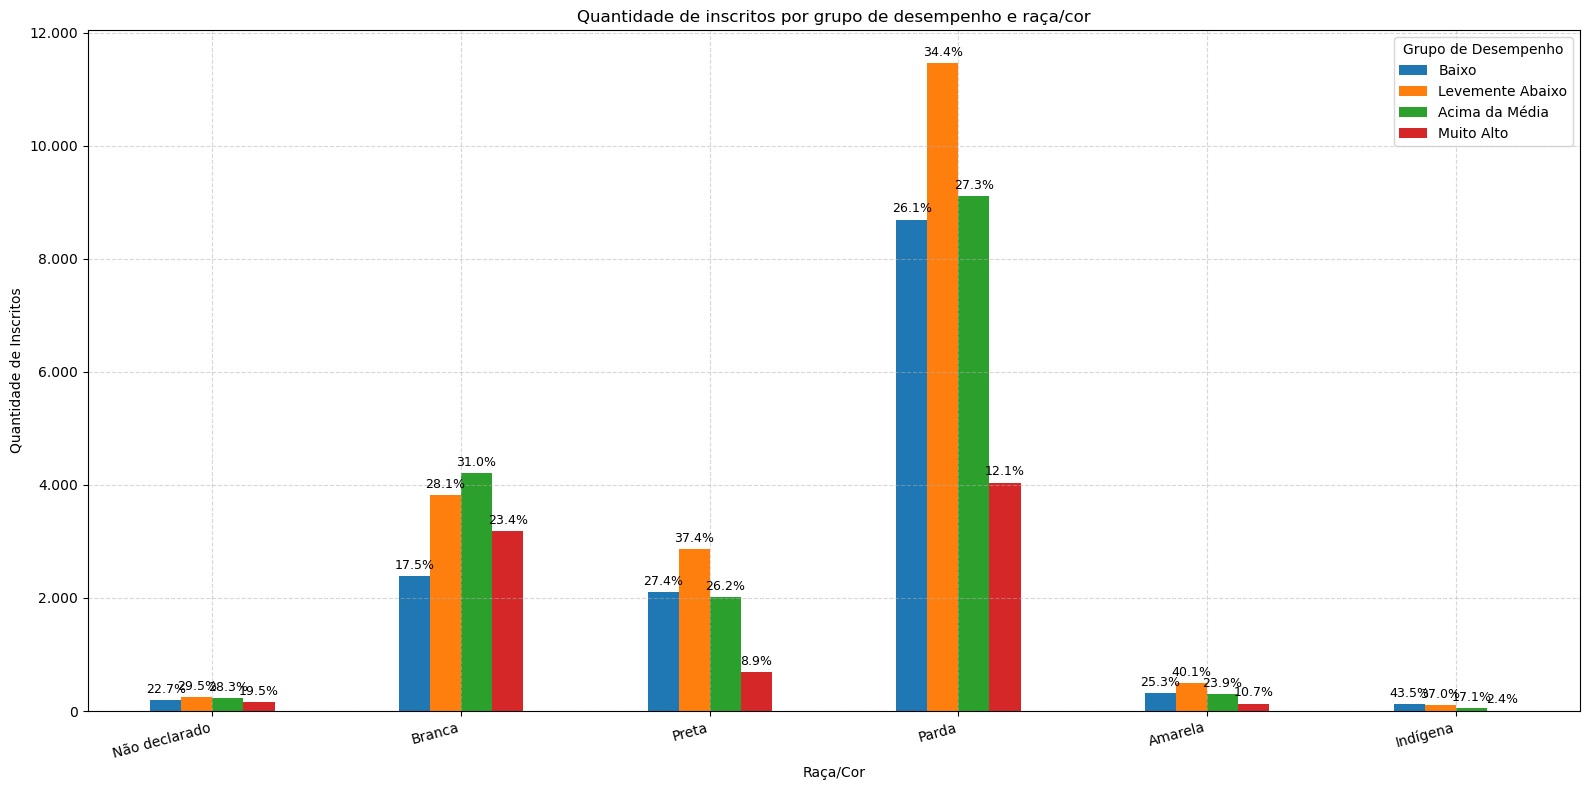

In [20]:
# ============================================================
# 1️⃣ Base de Dados
# ============================================================
base = df_ifnmg.copy() if "df_ifnmg" in globals() else df_final.copy()


# ============================================================
# 2️⃣ Garantia da variável TP_COR_RACA
# ============================================================
if "TP_COR_RACA" not in base.columns:
    dummy_cols = [c for c in base.columns if c.startswith("COR_RACA_")]
    if not dummy_cols:
        raise ValueError(
            "Não encontrei TP_COR_RACA nem colunas COR_RACA_* na base."
        )

    base["TP_COR_RACA"] = (
        base[dummy_cols]
        .idxmax(axis=1)
        .str.replace("COR_RACA_", "", regex=False)
        .astype(int)
    )


# ============================================================
# 3️⃣ Seleção das notas e da raça/cor
# ============================================================
cols_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = (
    base[["TP_COR_RACA"] + cols_notas]
    .dropna(subset=cols_notas)
    .copy()
)


# ============================================================
# 4️⃣ Clusterização (caso Cluster ainda não exista)
# ============================================================
if "Cluster" not in notas.columns:
    X = notas[cols_notas].values

    # Normalização apenas para o K-Means
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    k = 4
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels_raw = km.fit_predict(Xz)

    # Renomeação semântica dos clusters
    centers = km.cluster_centers_
    centers_mean = centers.mean(axis=1)
    order = np.argsort(centers_mean)  # do pior ao melhor

    old2rank = {old: r for r, old in enumerate(order)}
    rank2name = {
        0: "Baixo",
        1: "Levemente Abaixo",
        2: "Acima da Média",
        3: "Muito Alto"
    }

    notas["cluster_id"] = labels_raw
    notas["Cluster"] = notas["cluster_id"].map(old2rank).map(rank2name)


# ============================================================
# 5️⃣ Contagem por Raça/Cor e Cluster
# ============================================================
contagem_raca = (
    notas
    .groupby(["TP_COR_RACA", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)

ordem_raca = [0, 1, 2, 3, 4, 5]
ordem_clusters = [
    "Baixo",
    "Levemente Abaixo",
    "Acima da Média",
    "Muito Alto"
]

tabela = (
    contagem_raca
    .pivot(
        index="TP_COR_RACA",
        columns="Cluster",
        values="Quantidade"
    )
    .reindex(
        index=[r for r in ordem_raca
               if r in contagem_raca["TP_COR_RACA"].unique()],
        columns=ordem_clusters
    )
    .fillna(0)
    .astype(int)
)


# ============================================================
# 6️⃣ Rótulos de Raça/Cor
# ============================================================
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena"
}
tabela.index = [mapa_raca.get(i, i) for i in tabela.index]


# ============================================================
# 7️⃣ Tabela com Totais
# ============================================================
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)

print("\nTabela Raça/Cor × Cluster (valores absolutos):\n")
print(tabela_tot)


# ============================================================
# 8️⃣ Percentuais por Raça/Cor
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


# ============================================================
# 9️⃣ Gráfico — Distribuição por Raça/Cor
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))

tabela.plot(kind="bar", ax=ax)

ax.set_title("Quantidade de inscritos por grupo de desempenho e raça/cor")
ax.set_xlabel("Raça/Cor")
ax.set_ylabel("Quantidade de Inscritos")
ax.set_xticklabels(tabela.index, rotation=15, ha="right")
ax.legend(title="Grupo de Desempenho")

# Formatação do eixo Y
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

ax.grid(True, linestyle="--", alpha=0.5)

# Percentuais sobre as barras
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


In [21]:
# ============================================================
# 🔟 TABELA ANO × RAÇA/COR × CLUSTER
# ============================================================

# Garantir que NU_ANO esteja na base
if "NU_ANO" not in base.columns:
    raise ValueError("A variável NU_ANO não está disponível na base.")

# Reconstruir base com ano
notas_ano = (
    base[["NU_ANO", "TP_COR_RACA"] + cols_notas]
    .dropna(subset=cols_notas)
    .copy()
)

# Se Cluster já existir na base principal, reaproveitar
if "Cluster" in base.columns:
    notas_ano["Cluster"] = base.loc[notas_ano.index, "Cluster"]
else:
    notas_ano["Cluster"] = notas.loc[notas_ano.index, "Cluster"]

# ------------------------------------------------------------
# Contagem por Ano, Raça/Cor e Cluster
# ------------------------------------------------------------
contagem_ano = (
    notas_ano
    .groupby(["NU_ANO", "TP_COR_RACA", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)

tabela_ano = (
    contagem_ano
    .pivot_table(
        index=["NU_ANO", "TP_COR_RACA"],
        columns="Cluster",
        values="Quantidade",
        aggfunc="sum",
        observed=True
    )
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)

# Ajustar rótulos de raça/cor
tabela_ano = tabela_ano.reset_index()
tabela_ano["TP_COR_RACA"] = tabela_ano["TP_COR_RACA"].map(mapa_raca)
tabela_ano = tabela_ano.set_index(["NU_ANO", "TP_COR_RACA"])

print("\nTabela Ano × Raça/Cor × Cluster (valores absolutos):\n")
print(tabela_ano)

# ============================================================
# 1️⃣1️⃣ Percentual por Ano × Raça/Cor
# ============================================================

percent_ano = (
    tabela_ano
    .div(tabela_ano.sum(axis=1), axis=0)
    * 100
).round(1)

print("\nTabela Ano × Raça/Cor × Cluster (percentual):\n")
print(percent_ano)



Tabela Ano × Raça/Cor × Cluster (valores absolutos):

Cluster               Baixo  Levemente Abaixo  Acima da Média  Muito Alto
NU_ANO TP_COR_RACA                                                       
2018   Não declarado     38                77              78          48
       Branca           522              1030            1108         703
       Preta            505              1038             734         234
       Parda           1921              4064            3102        1209
       Amarela           82               186             129          50
       Indígena          30                47              22           3
2019   Não declarado     57                63              46          31
       Branca           622               889             751         469
       Preta            747               830             429         121
       Parda           3023              3214            1939         686
       Amarela           88               156            

Entre os estudantes que se declaram brancos, observa-se uma distribuição relativamente mais favorável: cerca de 31% estão no grupo Acima da Média e aproximadamente 24% no grupo Muito Alto. Somando esses dois grupos, mais da metade dos estudantes brancos se encontra em níveis de desempenho acima da média. A participação nos grupos Baixo e Levemente Abaixo é menor quando comparada a outras categorias.

Entre os estudantes pretos e pardos, percebe-se maior concentração nos grupos de desempenho inferiores. Para os pretos, algo em torno de 27% está no grupo Baixo e cerca de 38% em Levemente Abaixo, enquanto apenas uma parcela bem menor atinge o grupo Muito Alto. Entre os pardos, a maior parte também se concentra em Baixo e Levemente Abaixo, com proporção menor nos níveis superiores quando comparados aos brancos.

Nos estudantes amarelos, a distribuição é mais concentrada nos grupos intermediários, especialmente Levemente Abaixo, com uma fatia mais modesta em Muito Alto. Já entre os indígenas, a proporção no grupo Baixo é bastante elevada, e a presença nos níveis Acima da Média e Muito Alto é bem menor, indicando um cenário de maior vulnerabilidade educacional.


Para o grupo não declarado, as porcentagens se distribuem de maneira intermediária, sem um destaque claro em desempenho muito alto, o que pode estar ligado tanto ao perfil dos estudantes quanto a possíveis particularidades dessa categoria (por exemplo, tamanho de amostra menor ou perfis heterogêneos).

De forma geral, o gráfico evidencia que estudantes brancos tendem a ter maior participação nos grupos de melhor desempenho, enquanto estudantes pretos, pardos, amarelos e indígenas estão proporcionalmente mais concentrados nos níveis abaixo da média.

## **Quantidade de inscritos por grupo para cada faixa de renda mensal**

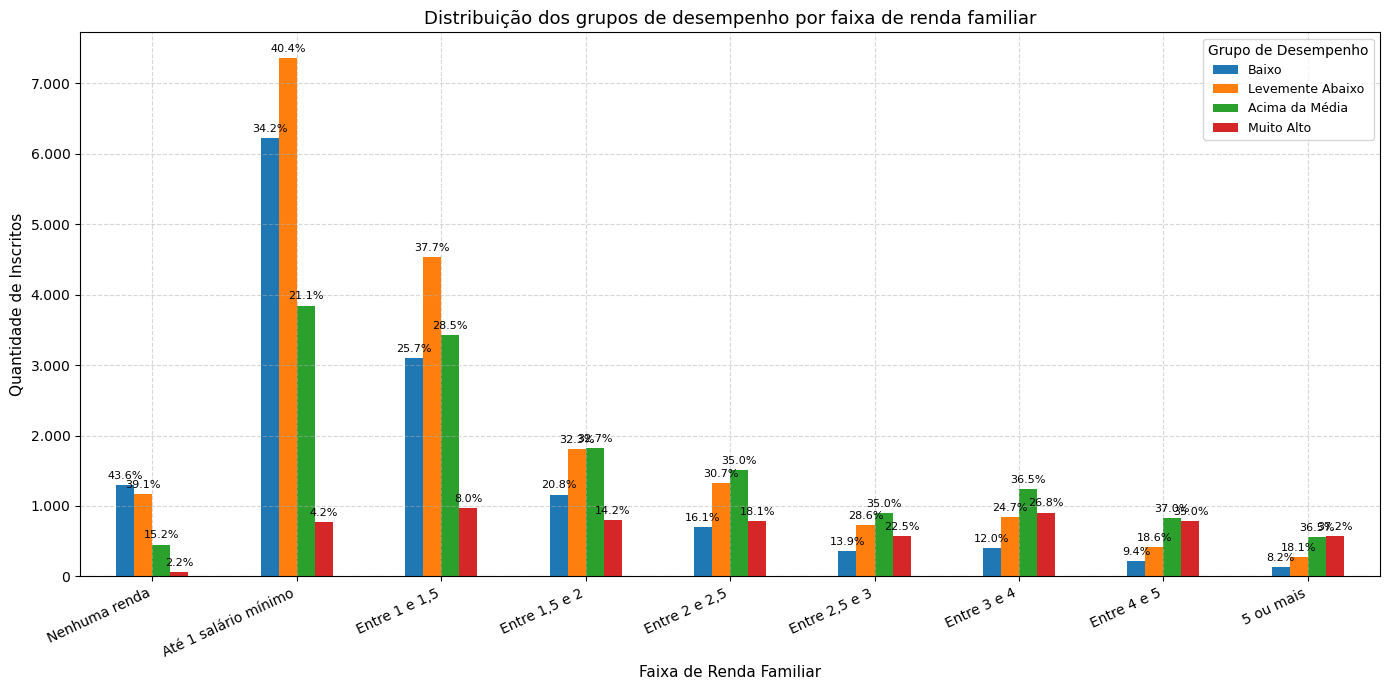

In [23]:
# ============================================================
# 1️⃣ Base de Dados
# ============================================================
base = df_ifnmg.copy()


# ============================================================
# 2️⃣ Garantia da variável RENDA_MENSAL
# ============================================================
if "RENDA_MENSAL" not in base.columns:
    renda_dummies = [c for c in base.columns if c.startswith("RENDA_MENSAL_")]
    if not renda_dummies:
        raise ValueError(
            "Não encontrei coluna 'RENDA_MENSAL' nem dummies 'RENDA_MENSAL_*'."
        )

    base["RENDA_MENSAL"] = (
        base[renda_dummies]
        .idxmax(axis=1)
        .str.replace("RENDA_MENSAL_", "", regex=False)
    )


# ============================================================
# 3️⃣ Seleção das notas e renda
# ============================================================
cols_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = (
    base[["RENDA_MENSAL"] + cols_notas]
    .dropna(subset=cols_notas)
    .copy()
)


# ============================================================
# 4️⃣ Clusterização (caso Cluster ainda não exista)
# ============================================================
if "Cluster" not in notas.columns:
    X = notas[cols_notas].values

    # Normalização apenas para o K-Means
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    k = 4
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels_raw = km.fit_predict(Xz)

    # Renomeação semântica dos clusters
    centers = km.cluster_centers_
    centers_mean = centers.mean(axis=1)
    ordem = np.argsort(centers_mean)  # do pior ao melhor

    old2rank = {old: r for r, old in enumerate(ordem)}
    rank2name = {
        0: "Baixo",
        1: "Levemente Abaixo",
        2: "Acima da Média",
        3: "Muito Alto"
    }

    notas["cluster_id"] = labels_raw
    notas["Cluster"] = notas["cluster_id"].map(old2rank).map(rank2name)


# ============================================================
# 5️⃣ Mapeamento das faixas de renda
# ============================================================
mapa_renda = {
    "A": "Nenhuma renda",
    "B": "Até 1 salário mínimo",
    "C": "Entre 1 e 1,5",
    "D": "Entre 1,5 e 2",
    "E": "Entre 2 e 2,5",
    "F": "Entre 2,5 e 3",
    "G": "Entre 3 e 4",
    "H": "Entre 4 e 5",
    "I": "5 ou mais"
}

# Mantém apenas categorias válidas
notas = notas[notas["RENDA_MENSAL"].isin(mapa_renda.keys())].copy()
notas["Faixa_Renda"] = notas["RENDA_MENSAL"].map(mapa_renda)


# ============================================================
# 6️⃣ Contagem por Faixa de Renda e Cluster
# ============================================================
contagem_renda = (
    notas
    .groupby(["Faixa_Renda", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)

ordem_clusters = [
    "Baixo",
    "Levemente Abaixo",
    "Acima da Média",
    "Muito Alto"
]

ordem_renda = [
    "Nenhuma renda",
    "Até 1 salário mínimo",
    "Entre 1 e 1,5",
    "Entre 1,5 e 2",
    "Entre 2 e 2,5",
    "Entre 2,5 e 3",
    "Entre 3 e 4",
    "Entre 4 e 5",
    "5 ou mais"
]

tabela = (
    contagem_renda
    .pivot(
        index="Faixa_Renda",
        columns="Cluster",
        values="Quantidade"
    )
    .reindex(index=ordem_renda, columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)


# ============================================================
# 7️⃣ Percentuais por Faixa de Renda
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


# ============================================================
# 8️⃣ Gráfico — Distribuição por Faixa de Renda
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

tabela.plot(kind="bar", ax=ax)

ax.set_title(
    "Distribuição dos grupos de desempenho por faixa de renda familiar",
    fontsize=13
)
ax.set_xlabel("Faixa de Renda Familiar", fontsize=11)
ax.set_ylabel("Quantidade de Inscritos", fontsize=11)
ax.set_xticklabels(tabela.index, rotation=25, ha="right")
ax.legend(title="Grupo de Desempenho", fontsize=9)

ax.grid(True, linestyle="--", alpha=0.5)

# Formatação do eixo Y
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

# Percentuais sobre as barras
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 9️⃣ RENDA × ANO × CLUSTER
# ============================================================

# Garantir que NU_ANO exista
if "NU_ANO" not in base.columns:
    raise ValueError("A variável NU_ANO não está disponível na base.")

# Reconstruir base com ano
notas_ano = (
    base[["NU_ANO", "RENDA_MENSAL"] + cols_notas]
    .dropna(subset=cols_notas)
    .copy()
)

# Manter apenas faixas válidas
notas_ano = notas_ano[
    notas_ano["RENDA_MENSAL"].isin(mapa_renda.keys())
].copy()

notas_ano["Faixa_Renda"] = notas_ano["RENDA_MENSAL"].map(mapa_renda)

# Reaproveitar cluster já calculado
if "Cluster" in base.columns:
    notas_ano["Cluster"] = base.loc[notas_ano.index, "Cluster"]
else:
    notas_ano["Cluster"] = notas.loc[notas_ano.index, "Cluster"]

# ------------------------------------------------------------
# Contagem por Ano, Renda e Cluster
# ------------------------------------------------------------
contagem_ano = (
    notas_ano
    .groupby(["NU_ANO", "Faixa_Renda", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)

tabela_ano = (
    contagem_ano
    .pivot_table(
        index=["NU_ANO", "Faixa_Renda"],
        columns="Cluster",
        values="Quantidade",
        aggfunc="sum",
        observed=True
    )
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)

print("\nTabela Ano × Faixa de Renda × Cluster (valores absolutos):\n")
print(tabela_ano)


# ============================================================
# 🔟 Percentual por Ano × Faixa de Renda
# ============================================================

percent_ano = (
    tabela_ano
    .div(tabela_ano.sum(axis=1), axis=0)
    * 100
).round(1)

print("\nTabela Ano × Faixa de Renda × Cluster (percentual):\n")
print(percent_ano)



Tabela Ano × Faixa de Renda × Cluster (valores absolutos):

Cluster                      Baixo  Levemente Abaixo  Acima da Média  \
NU_ANO Faixa_Renda                                                     
2018   5 ou mais                20                72             156   
       Até 1 salário mínimo   1487              2709            1515   
       Entre 1 e 1,5           813              1798            1375   
       Entre 1,5 e 2           189               439             491   
       Entre 2 e 2,5           143               402             477   
       Entre 2,5 e 3            34               135             178   
       Entre 3 e 4              58               215             320   
       Entre 4 e 5              21                89             164   
       Nenhuma renda           296               470             186   
2019   5 ou mais                33                70             111   
       Até 1 salário mínimo   2195              2161             826   
   

**1. Faixas de renda mais baixas – até 1,5 salário mínimo**

Entre os estudantes com nenhuma renda ou até 1 salário mínimo, há forte concentração nos grupos de desempenho mais baixos.

Na faixa até 1 salário mínimo, 40,6% dos inscritos estão no grupo Levemente Abaixo e 33,4% no grupo Baixo, somando cerca de 74% abaixo da média.

Apenas 21,7% estão Acima da Média e 4,3% no grupo Muito Alto, o que evidencia uma grande desigualdade de desempenho associada à renda.

Entre os estudantes sem renda, o padrão é semelhante: 42,9% estão no grupo Baixo e apenas 2,2% no Muito Alto.

**2. Renda intermediária – entre 1,5 e 3 salários mínimos**

Nas faixas intermediárias, o desempenho melhora de forma gradual.

Os grupos Acima da Média passam a ganhar representatividade, chegando a 35,3% entre os alunos com renda de 2 a 2,5 salários mínimos.

Observa-se uma redução progressiva da proporção de alunos no grupo Baixo, que cai de mais de 40% nas faixas iniciais para cerca de 15% nas rendas entre 2 e 3 salários.
Isso sugere que o aumento da renda familiar está diretamente relacionado a melhores condições de desempenho escolar.

**3. Renda mais alta – acima de 3 salários mínimos**

Nas faixas de renda mais altas, o cenário se inverte.

A participação nos grupos de melhor desempenho (Acima da Média e Muito Alto) supera 50% em praticamente todas as categorias a partir de 3 salários mínimos.

Por exemplo, entre os alunos com renda de 3 a 4 salários, 36% estão Acima da Média e 27,3% no grupo Muito Alto, totalizando mais de 63% com desempenho acima da média.

O mesmo padrão se repete entre os que possuem renda superior a 4 salários, nos quais os grupos de baixo desempenho somam menos de 30%.



O gráfico evidencia uma relação direta entre renda e desempenho escolar:
quanto maior a renda familiar, menor a proporção de estudantes nos grupos de baixo desempenho e maior a concentração nos grupos de desempenho elevado.

Esses resultados reforçam o impacto das condições socioeconômicas sobre o desempenho acadêmico. Estudantes de famílias com menor renda tendem a enfrentar maiores desafios de acesso, infraestrutura, apoio pedagógico e recursos educacionais, o que se reflete nas notas.

Já nas faixas de renda mais altas, a melhor distribuição de recursos e oportunidades parece favorecer o desempenho, ampliando a proporção de alunos com resultados acima da média.